# Backtest Evaluation: Walk-Forward Analysis on 2026 Data
**Objective:** Unseal the 2026 test data and evaluate the end-to-end DeepVol pipeline. We will simulate the live C++ execution environment by walking forward bar-by-bar, generating predictions, sizing positions, and logging trades. Finally, we grade the model on Sharpe Ratio, Maximum Drawdown, and Volatility Band Coverage.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Add src to path
sys.path.append(os.path.abspath('../src'))

from data_pipeline.preprocessor import MarketDataPreprocessor
from features.technicals import TechnicalFeatures
from features.microstructure import MicrostructureFeatures
from models.inference import DeepVolInferenceEngine
from strategy.vwap_mean_reversion import VWAPMeanReversionStrategy
from strategy.position_sizing import KellyVolatilitySizer
from strategy.metrics import BacktestMetrics

# Plotting config
plt.style.use('dark_background')
sns.set_palette("bright")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

## 1. Prepare the Out-of-Sample Test Environment
We must load the strictly held-out 2026 dataset. To ensure zero lookahead bias, we will quickly re-fit our `StandardScaler` strictly on the pre-2026 training data before applying it to the 2026 test data.

In [2]:
print("Initializing Preprocessing Pipeline...")
preprocessor = MarketDataPreprocessor()
tech_builder = TechnicalFeatures(bars_per_day=288)
micro_builder = MicrostructureFeatures()

# 1. Fit Scaler on TRAIN Data (Strictly pre-2026)
train_raw_path = '../data/raw/ETHUSDT_5m_2024-01-01_to_2026-01-01.csv'
df_train = pd.read_csv(train_raw_path, index_col=0, parse_dates=True)
df_train = preprocessor.force_time_grid(df_train)
df_train = preprocessor.compute_log_returns(df_train)
df_train = tech_builder.generate_all(df_train, drop_nans=True)
df_train = micro_builder.generate_all(df_train)

features_to_scale = [
    'log_return', 'log_volume_usdt', 'rv_1h', 'rv_1d', 'rv_1w', 
    'garman_klass_vol', 'rsi_14', 'ema_ratio', 'avg_trade_size', 
    'volume_z_score', 'amihud_illiquidity', 'vol_imbalance', 'vol_to_vol_ratio'
]
_ = preprocessor.fit_transform_scaler(df_train, features_to_scale)
print("Scaler fitted on pre-2026 data.")
del df_train # Free memory

# 2. Process the 2026 TEST Data
test_raw_path = '../data/raw/ETHUSDT_5m_2026-01-01_to_2026-06-01.csv'
if not os.path.exists(test_raw_path):
    raise FileNotFoundError(f"Missing 2026 data at {test_raw_path}")

df_test = pd.read_csv(test_raw_path, index_col=0, parse_dates=True)
df_test = preprocessor.force_time_grid(df_test)
df_test = preprocessor.compute_log_returns(df_test)
df_test = tech_builder.generate_all(df_test, drop_nans=True)
df_test = micro_builder.generate_all(df_test)

# Scale using the Train-fitted scaler
df_test_scaled = preprocessor.transform_scaler(df_test, features_to_scale)

# We need all engineered features for the models
ALL_FEATURES = features_to_scale + ['sin_day', 'cos_day', 'sin_week', 'cos_week']
test_matrix = df_test_scaled[ALL_FEATURES].values
close_prices = df_test['close'].values
raw_returns = df_test['log_return'].values

print(f"Test Environment Ready. 2026 Bars: {len(test_matrix)}")

Initializing Preprocessing Pipeline...


2026-06-25 12:01:11,934 - INFO - Forcing continuous time grid...
2026-06-25 12:01:11,945 - INFO - Grid fill complete. Final shape: (210529, 9)
2026-06-25 12:01:11,945 - INFO - Computing Log Returns...
2026-06-25 12:01:11,963 - INFO - Computing HAR Volatility lags (1h, 1d, 1w)...
2026-06-25 12:01:11,971 - INFO - Computing Garman-Klass Volatility...
2026-06-25 12:01:11,974 - INFO - Computing RSI and EMA Ratio...
2026-06-25 12:01:11,982 - INFO - Computing Sin/Cos seasonality encodings...
2026-06-25 12:01:12,002 - INFO - Dropped 2015 rows due to feature warm-up periods.
2026-06-25 12:01:12,026 - INFO - Computing Whale Tracker features...
2026-06-25 12:01:12,032 - INFO - Computing Amihud Illiquidity...
2026-06-25 12:01:12,033 - INFO - Computing Volume Imbalance...
2026-06-25 12:01:12,034 - INFO - Computing Volatility-to-Volume Ratio...
2026-06-25 12:01:12,036 - INFO - Fitting and applying StandardScaler (Training Mode)...
2026-06-25 12:01:12,233 - INFO - Forcing continuous time grid...
2026

Scaler fitted on pre-2026 data.
Test Environment Ready. 2026 Bars: 41473


## 2. Initialize Models & Strategy Engine
We load the `DeepVolInferenceEngine` with our saved `.pth` and `.pkl` weights. We also initialize the `VWAPMeanReversionStrategy` and the `KellyVolatilitySizer`.

In [3]:
vol_weights = '../weights/vol_lstm_best.pth'
regime_weights = '../weights/regime_lstm_best.pth'

print("Loading DeepVol Inference Engine...")
engine = DeepVolInferenceEngine(num_features=len(ALL_FEATURES), 
                                vol_weights_path=vol_weights, 
                                regime_weights_path=regime_weights)

# Initialize Strategy
strategy = VWAPMeanReversionStrategy(z_score_threshold=2, base_risk_fraction=0.05)
sizer = KellyVolatilitySizer(kelly_fraction=0.5, max_capital_risk=0.25)

2026-06-25 12:01:26,973 - INFO - Initializing Inference Engine on cpu...
2026-06-25 12:01:26,974 - INFO - Initializing VolatilityLSTM: Input=17, Hidden=32, Layers=2
2026-06-25 12:01:26,986 - INFO - Initializing RegimeLSTM: Input=17, Hidden=32, Layers=2, Classes=3
2026-06-25 12:01:26,994 - INFO - Volatility LSTM weights loaded successfully.
2026-06-25 12:01:26,996 - INFO - Regime LSTM weights loaded successfully.
2026-06-25 12:01:26,996 - INFO - Inference Engine ready. Models locked in eval mode.
2026-06-25 12:01:26,997 - INFO - Initialized VWAP Mean Reversion Strategy (Threshold: 2σ, Base Risk: 5.0%)
2026-06-25 12:01:26,997 - INFO - Initialized KellyVolatilitySizer (Fraction: 0.5, Max Risk: 25.0%)


Loading DeepVol Inference Engine...


## 3. Walk-Forward Simulation Loop
This loop simulates real-time deployment. It steps through the 2026 dataset one bar at a time. The models only ever see $t-78$ to $t$. No future data is accessible.

In [4]:
# --- Backtest State Variables ---
INITIAL_CAPITAL = 10000.0
capital = INITIAL_CAPITAL
holdings = 0.0
equity_curve = []

# Logs
trade_log = []
pred_vols_log = []
regime_log = []

# Minimum bars needed for the Volatility LSTM
WINDOW = 78  

print("Starting Walk-Forward Backtest Simulation...")
for i in tqdm(range(WINDOW, len(test_matrix))):
    
    # 1. State extraction (Current Price, VWAP calculation over the day)
    current_px = close_prices[i]
    
    # Simple rolling 1-day VWAP (288 bars)
    vwap_start = max(0, i - 288)
    typical_prices = (df_test['high'].iloc[vwap_start:i] + df_test['low'].iloc[vwap_start:i] + df_test['close'].iloc[vwap_start:i]) / 3
    volumes = df_test['volume_usdt'].iloc[vwap_start:i]
    vwap = (typical_prices * volumes).sum() / (volumes.sum() + 1e-8)
    
    # Record Portfolio Equity (Cash + Value of Holdings)
    current_equity = capital + (holdings * current_px)
    equity_curve.append(current_equity)
    
    # 2. Get Model Predictions
    seq = test_matrix[i-WINDOW:i]
    predictions = engine.predict_all(seq)
    
    p_vol = predictions['predicted_volatility']
    p_regime = predictions['regime_probabilities']
    
    pred_vols_log.append(p_vol)
    regime_log.append(p_regime)
    
    # 3. Strategy Execution Logic
    orders = strategy.execute(
        current_price=current_px,
        vwap=vwap,
        predicted_vol=p_vol,
        regime_probs=p_regime,
        available_capital=capital,
        current_holdings=holdings
    )
    
    # 4. Handle Sizing and Order Filling
    if orders['sell'] > 0:
        # Execute Sell
        sell_amount = orders['sell']
        revenue = sell_amount * current_px
        capital += revenue
        holdings -= sell_amount
        
        trade_log.append({
            'time': df_test.index[i],
            'action': 'SELL',
            'price': current_px,
            'amount': sell_amount,
            'value': revenue
        })
        
    elif orders['buy'] > 0 and holdings == 0:
        # Recalculate size using the Kelly Volatility targeter
        target_shares = sizer.get_target_shares(
            available_capital=capital,
            current_price=current_px,
            predicted_vol=p_vol,
            regime_confidence=p_regime["State_2_Chop"]
        )
        
        if target_shares > 0:
            cost = target_shares * current_px
            capital -= cost
            holdings += target_shares
            
            trade_log.append({
                'time': df_test.index[i],
                'action': 'BUY',
                'price': current_px,
                'amount': target_shares,
                'value': cost
            })

    # Temporary Debug Injection
    if i % 2000 == 0: # Print every ~1 week of data
        lower_b = vwap - (2.0 * p_vol * current_px)
        print(f"\n--- Debug Bar {i} ---")
        print(f"Price: {current_px:.2f} | VWAP: {vwap:.2f} | Lower Band: {lower_b:.2f}")
        print(f"Predicted Vol: {p_vol:.5f} | Chop Prob: {p_regime['State_2_Chop']:.2f}")
        print(f"Distance to buy trigger: {current_px - lower_b:.2f} USDT")

# Final Portfolio Liquidation at the end of the test
if holdings > 0:
    capital += holdings * close_prices[-1]
    holdings = 0
    equity_curve.append(capital)

print("\nSimulation Complete!")

Starting Walk-Forward Backtest Simulation...


  0%|          | 0/41395 [00:00<?, ?it/s]2026-06-25 12:01:34,378 - INFO - Oversold anomaly detected: Price 3129.82 < Lower Band 3131.29
2026-06-25 12:01:34,379 - INFO - Executing BUY: 0.0702 ETH at 3129.82. Total Allocation: $219.86
2026-06-25 12:01:34,379 - INFO - Sizing Logic -> Kelly Wgt: 0.498 | Vol Scalar: 0.44 | Final Risk: 22.0% | Allocation: $2198.55
  0%|          | 34/41395 [00:00<02:02, 338.71it/s]2026-06-25 12:01:34,435 - INFO - Trend Regime Detected (Up: 0.91, Down: 0.01). Flattening portfolio.
2026-06-25 12:01:34,453 - INFO - Oversold anomaly detected: Price 3121.23 < Lower Band 3126.13
2026-06-25 12:01:34,453 - INFO - Executing BUY: 0.0189 ETH at 3121.23. Total Allocation: $59.05
2026-06-25 12:01:34,454 - INFO - Sizing Logic -> Kelly Wgt: 0.137 | Vol Scalar: 0.43 | Final Risk: 5.9% | Allocation: $590.47
2026-06-25 12:01:34,458 - INFO - Trend Regime Detected (Up: 0.62, Down: 0.00). Flattening portfolio.
2026-06-25 12:01:34,463 - INFO - Oversold anomaly detected: Price 312


--- Debug Bar 2000 ---
Price: 3352.82 | VWAP: 3340.91 | Lower Band: 3033.06
Predicted Vol: 0.04591 | Chop Prob: 0.28
Distance to buy trigger: 319.76 USDT


  5%|▌         | 2128/41395 [00:04<01:28, 443.48it/s]2026-06-25 12:01:39,144 - INFO - Oversold anomaly detected: Price 3318.45 < Lower Band 3330.58
2026-06-25 12:01:39,145 - INFO - Executing BUY: 0.0346 ETH at 3318.45. Total Allocation: $114.83
2026-06-25 12:01:39,145 - INFO - Sizing Logic -> Kelly Wgt: 0.306 | Vol Scalar: 0.38 | Final Risk: 11.5% | Allocation: $1148.34
2026-06-25 12:01:39,148 - INFO - Trend Regime Detected (Up: 0.99, Down: 0.01). Flattening portfolio.
  5%|▌         | 2173/41395 [00:04<01:28, 443.47it/s]2026-06-25 12:01:39,252 - INFO - Oversold anomaly detected: Price 3304.62 < Lower Band 3316.35
2026-06-25 12:01:39,252 - INFO - Executing BUY: 0.0159 ETH at 3304.62. Total Allocation: $52.76
2026-06-25 12:01:39,252 - INFO - Sizing Logic -> Kelly Wgt: 0.159 | Vol Scalar: 0.33 | Final Risk: 5.3% | Allocation: $527.59
  5%|▌         | 2219/41395 [00:04<01:27, 445.34it/s]2026-06-25 12:01:39,327 - INFO - Price reverted to VWAP (3325.72 >= 3325.04). Securing profits.
2026-06


--- Debug Bar 4000 ---
Price: 3035.98 | VWAP: 2961.58 | Lower Band: 2719.08
Predicted Vol: 0.03994 | Chop Prob: 0.00
Distance to buy trigger: 316.90 USDT


...


--- Debug Bar 38000 ---
Price: 2107.58 | VWAP: 2121.12 | Lower Band: 2001.63
Predicted Vol: 0.02835 | Chop Prob: 1.00
Distance to buy trigger: 105.95 USDT


 92%|█████████▏| 38198/41395 [01:24<00:06, 462.85it/s]2026-06-25 12:02:59,084 - INFO - Oversold anomaly detected: Price 2118.90 < Lower Band 2121.08
2026-06-25 12:02:59,085 - INFO - Executing BUY: 0.0817 ETH at 2118.90. Total Allocation: $173.21
2026-06-25 12:02:59,085 - INFO - Sizing Logic -> Kelly Wgt: 0.497 | Vol Scalar: 0.35 | Final Risk: 17.5% | Allocation: $1732.08
2026-06-25 12:02:59,125 - INFO - Price reverted to VWAP (2129.24 >= 2128.84). Securing profits.
 93%|█████████▎| 38292/41395 [01:24<00:06, 459.08it/s]2026-06-25 12:02:59,313 - INFO - Oversold anomaly detected: Price 2128.57 < Lower Band 2129.27
2026-06-25 12:02:59,313 - INFO - Executing BUY: 0.1111 ETH at 2128.57. Total Allocation: $236.66
2026-06-25 12:02:59,314 - INFO - Sizing Logic -> Kelly Wgt: 0.500 | Vol Scalar: 0.48 | Final Risk: 23.9% | Allocation: $2366.63
2026-06-25 12:02:59,336 - INFO - Price reverted to VWAP (2134.78 >= 2134.32). Securing profits.
 93%|█████████▎| 38338/41395 [01:25<00:06, 456.75it/s]2026-0


--- Debug Bar 40000 ---
Price: 2074.98 | VWAP: 2099.99 | Lower Band: 1984.03
Predicted Vol: 0.02794 | Chop Prob: 1.00
Distance to buy trigger: 90.95 USDT


 97%|█████████▋| 40023/41395 [01:28<00:02, 460.56it/s]2026-06-25 12:03:03,138 - INFO - Trend Regime Detected (Up: 0.77, Down: 0.00). Flattening portfolio.
2026-06-25 12:03:03,145 - INFO - Oversold anomaly detected: Price 2083.35 < Lower Band 2088.35
2026-06-25 12:03:03,146 - INFO - Executing BUY: 0.0022 ETH at 2083.35. Total Allocation: $4.73
2026-06-25 12:03:03,146 - INFO - Sizing Logic -> Kelly Wgt: 0.011 | Vol Scalar: 0.42 | Final Risk: 0.5% | Allocation: $47.31
2026-06-25 12:03:03,148 - INFO - Trend Regime Detected (Up: 0.76, Down: 0.00). Flattening portfolio.
2026-06-25 12:03:03,151 - INFO - Oversold anomaly detected: Price 2083.03 < Lower Band 2088.22
2026-06-25 12:03:03,151 - INFO - Executing BUY: 0.0564 ETH at 2083.03. Total Allocation: $117.64
2026-06-25 12:03:03,151 - INFO - Sizing Logic -> Kelly Wgt: 0.287 | Vol Scalar: 0.42 | Final Risk: 11.9% | Allocation: $1176.41
 97%|█████████▋| 40070/41395 [01:28<00:02, 456.67it/s]2026-06-25 12:03:03,225 - INFO - Trend Regime Detected 


Simulation Complete!


## 4. Institutional Metric Evaluation
We now parse our trade logs and pass the arrays to `src/strategy/metrics.py`. We evaluate the **Sharpe Ratio**, **Maximum Drawdown**, and the critical **Band Coverage** (did 95% of reality stay inside our predicted limits?).


 DEEPVOL BACKTEST PERFORMANCE REPORT
 Initial Capital:    $10,000.00
 Final Capital:      $9,832.37
 Net Return:         -1.68%
--------------------------------------------------
 Annualized Sharpe:  -1.397
 Maximum Drawdown:   2.26%
 Band Coverage:      99.95% (Target: ~95.0%)
--------------------------------------------------
 Total Trades:       509
 Profit Factor:      0.63
 Est. Exchange Fees: $459.69



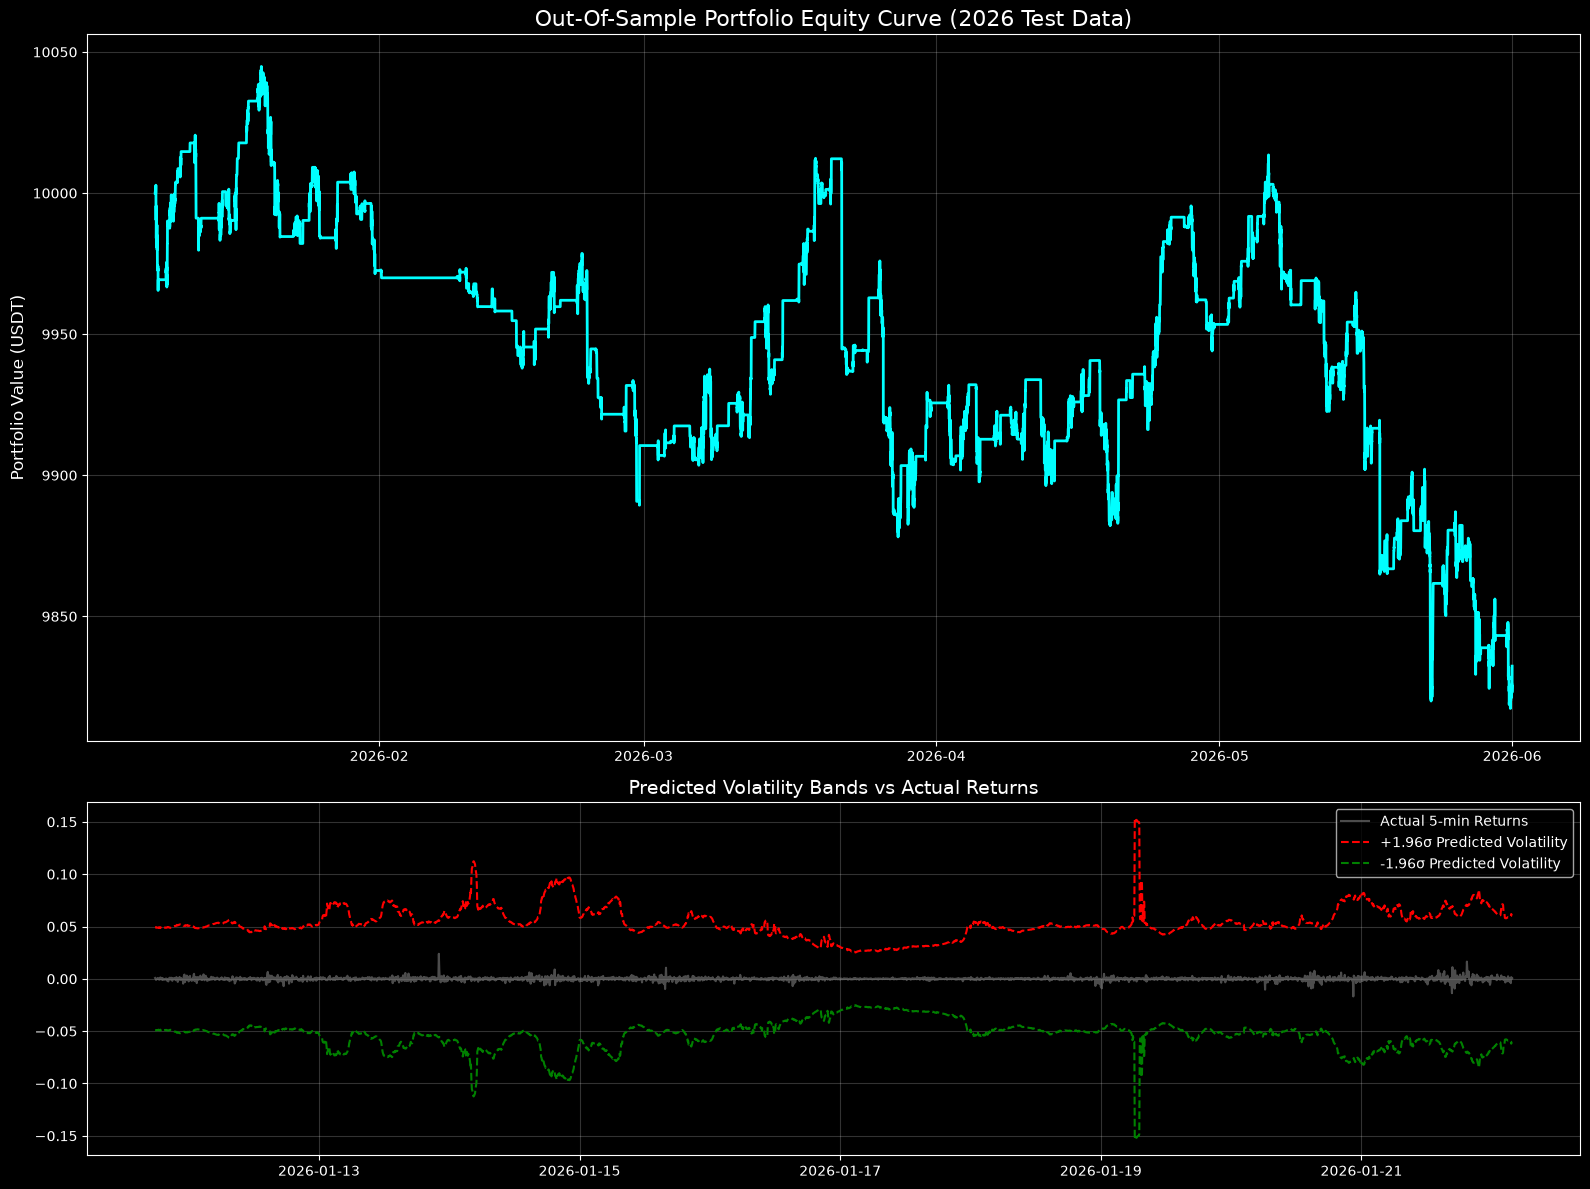

In [6]:
from strategy.metrics import BacktestMetrics

# 1. Format Data for the Grader
equity_series = pd.Series(equity_curve, index=df_test.index[WINDOW:WINDOW+len(equity_curve)])
pred_vol_series = pd.Series(pred_vols_log, index=df_test.index[WINDOW:])
actual_returns_series = pd.Series(raw_returns[WINDOW:], index=df_test.index[WINDOW:])

# Pair trades to calculate PnL per round-trip
paired_trades = []
buy_price = 0
buy_vol = 0
for t in trade_log:
    if t['action'] == 'BUY':
        buy_price = t['price']
        buy_vol = t['value']
    elif t['action'] == 'SELL' and buy_price > 0:
        pnl = t['value'] - buy_vol
        paired_trades.append({
            'pnl': pnl,
            'volume_traded': buy_vol
        })
        buy_price = 0

df_trades = pd.DataFrame(paired_trades)

# 2. Print Full Institutional Report
grader = BacktestMetrics(fee_bps=4.0) # Binance Futures VIP 0 rate
grader.print_full_report(equity_series, actual_returns_series, pred_vol_series, df_trades)

# 3. Plot Equity Curve
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(equity_series.index, equity_series.values, color='cyan', linewidth=2)
ax1.set_title('Out-Of-Sample Portfolio Equity Curve (2026 Test Data)', fontsize=16)
ax1.set_ylabel('Portfolio Value (USDT)', fontsize=12)

# 4. Plot Volatility Bands (Honest Band Proof)
# Slice a 2-week period to make it readable
start_idx = 1000
end_idx = 4000
time_slice = df_test.index[WINDOW+start_idx : WINDOW+end_idx]
ret_slice = actual_returns_series.iloc[start_idx:end_idx]
vol_slice = pred_vol_series.iloc[start_idx:end_idx]

upper_band = vol_slice * 1.96
lower_band = -vol_slice * 1.96

ax2.plot(time_slice, ret_slice, color='gray', alpha=0.6, label='Actual 5-min Returns')
ax2.plot(time_slice, upper_band, color='red', linestyle='--', label='+1.96σ Predicted Volatility')
ax2.plot(time_slice, lower_band, color='green', linestyle='--', label='-1.96σ Predicted Volatility')
ax2.set_title('Predicted Volatility Bands vs Actual Returns', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()